In [85]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
from scipy.interpolate import make_smoothing_spline
import os
lam = 20
import random

In [86]:
port = "/dev/cu.usbmodem1101"  # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True

Graph with 4 nodes and 3 edges
  name  isWeight Anode Bnode
0  BV0         0    A0    V0
1  BH0         0    A0    H0
2  W00         1    V0    H0
  name
0   A0
1   H0
2   V0


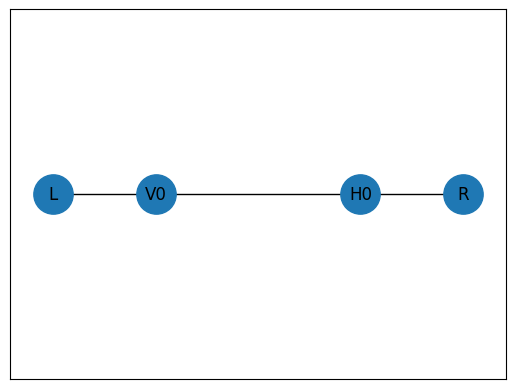

In [87]:
numV = 1
numH = 1

net = RKMNetwork(numV,numH)

net.draw_network()

print(net.edge)
print(net.node)

In [88]:
aConvert = (3.3)/(4095.)

In [89]:
RW = ReadWrite(ser)

In [90]:
RW.send_recieve("mvtst;-128;")

move test digi, -128
finished


In [91]:
digival = 0
deltadigi = 20
results = []
for i in range(7):
    RW.clear_output()
    time.sleep(1)
    RW.send_message("ames;0;")
    out = RW.measure()
    
    a0 = float(out['analogZero'])/int(out['nmestimes'])*aConvert
    
    time.sleep(1)
    RW.send_message("sampletemp;1000;1;")
    out = RW.measure()
    
    tempSig = [x*aConvert for x in out['analogTemp']]

    localresult = {'digi': digival, 'a0': a0, 'tempSig': tempSig}
    results.append(localresult)
    
    # plt.plot(tempSig, label=digival)
    # plt.hlines(a0, 0, len(tempSig))
    time.sleep(1)
    RW.send_recieve("mvtst;{};".format(deltadigi))
    time.sleep(1)
    digival += deltadigi

nmestimes, 5
analogZero, 12403
analogH, [12390]
finished
sampling temperature signal
analogTemp, [2464, 2467, 2469, 2475, 2474, 2483, 2484, 2493, 2489, 2492, 2498, 2504, 2511, 2495, 2513, 2511, 2519, 2515, 2524, 2513, 2530, 2532, 2535, 2538, 2544, 2584, 2545, 2543, 2543, 2538, 2537, 2535, 2529, 2531, 2526, 2523, 2516, 2515, 2525, 2475, 2511, 2496, 2497, 2506, 2495, 2489, 2489, 2479, 2477, 2472, 2475, 2469, 2463, 2454, 2459, 2461, 2459, 2450, 2443, 2443, 2444, 2445, 2429, 2432, 2425, 2421, 2423, 2419, 2430, 2438, 2426, 2436, 2433, 2435, 2442, 2447, 2446, 2449, 2455, 2432, 2468, 2463, 2467, 2466, 2475, 2503, 2487, 2478, 2485, 2489, 2491, 2504, 2504, 2510, 2508, 2509, 2511, 2512, 2514, 2524, 2524, 2532, 2531, 2537, 2543, 2542, 2546, 2548, 2547, 2530, 2550, 2545, 2538, 2532, 2531, 2517, 2513, 2521, 2518, 2512, 2511, 2507, 2501, 2536, 2497, 2496, 2494, 2476, 2493, 2482, 2478, 2470, 2472, 2476, 2451, 2463, 2461, 2453, 2451, 2476, 2455, 2443, 2439, 2435, 2437, 2450, 2412, 2421, 2419, 2418, 24

(array([1., 1., 2., 0., 1., 1., 0., 0., 0., 1.]),
 array([1.99579487, 1.99705201, 1.99830916, 1.9995663 , 2.00082344,
        2.00208059, 2.00333773, 2.00459487, 2.00585201, 2.00710916,
        2.0083663 ]),
 <BarContainer object of 10 artists>)

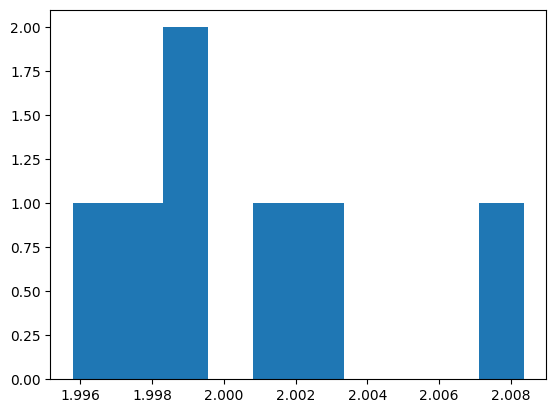

In [92]:
plt.hist([x['a0'] for x in results])

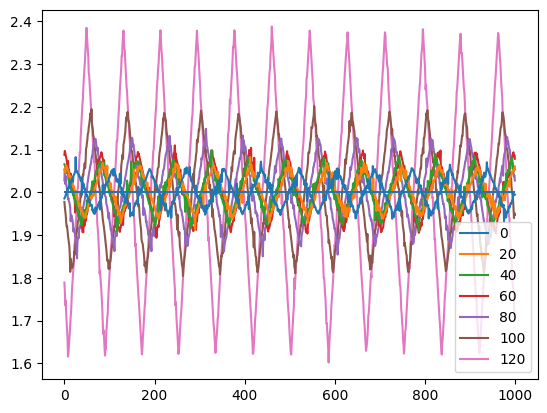

In [93]:
plt.hlines(np.mean([x['a0'] for x in results]), 0, len(results[0]['tempSig']))
for n in results:
    plt.plot(n['tempSig'], label=n['digi'], zorder=-1*n['digi'])

plt.legend()

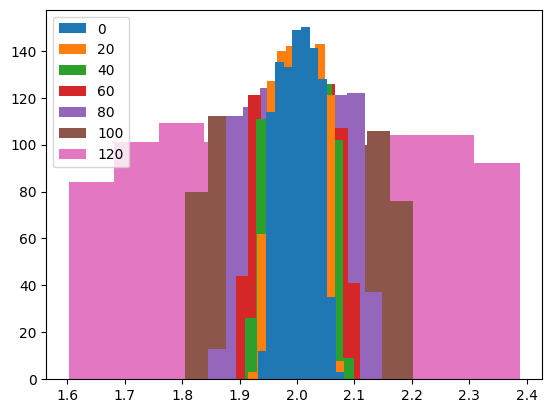

In [94]:
for n in results:
    plt.hist(n['tempSig'], label=n['digi'], zorder=-1*n['digi'])

plt.legend()

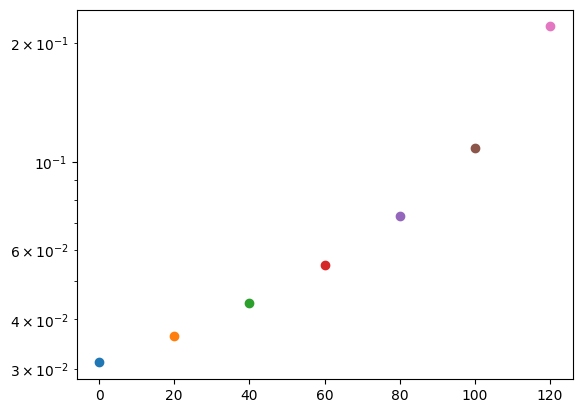

In [95]:
for n in results:
    stdev = np.std(n['tempSig'])
    # vrange = np.max(n['tempSig']) - np.min(n['tempSig'])
    plt.semilogy(n['digi'], stdev, 'o-')

In [96]:
for n in results:
    print(np.mean(n['tempSig']), n['a0'])

2.002 1.999018315018315
2.0021079853479855 1.9957948717948717
2.001975824175824 1.9985347985347985
2.001791282051282 2.0015970695970697
2.0011788278388276 2.0083663003663004
2.0008895238095237 1.9978901098901098
1.997338095238095 2.0025641025641026


In [84]:
ser.close()